In [16]:
import numpy as np

A = np.arange(1, 26).reshape(5, 5)
A

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25]])

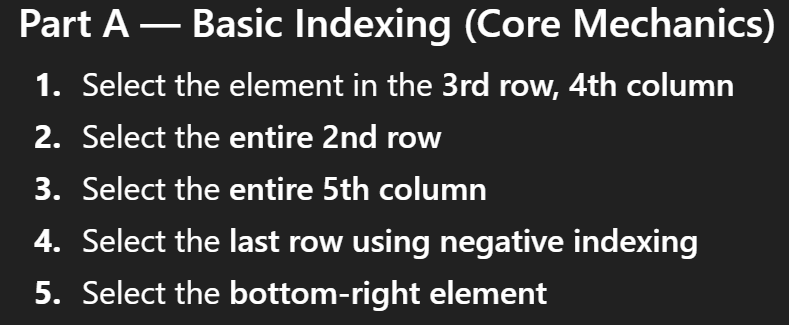

In [17]:
# 1. Select the element in the 3rd row, 4th column.
print(A[2, 3], "\n")

# 2. Select the entire 2nd row.
print(A[1], "\n")

# 3. Select the entire 5th row.
print(A[:, 4], "\n")

# 4. Select the last row using negative indexing
print(A[-1], "\n")

# 5. Select the bottom-right element
print(A[-1, -1], "\n")

14 

[ 6  7  8  9 10] 

[ 5 10 15 20 25] 

[21 22 23 24 25] 

25 



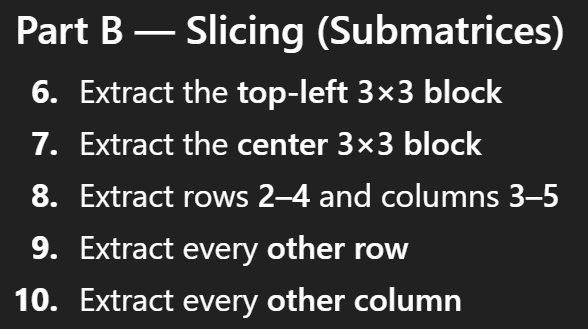

In [18]:
# 6. Extract the top-left 3×3 block
print(A[:3, :3], "\n")

# 7. Extract the center 3×3 block
print(A[1:4, 1:4], "\n")

# 8. Extract rows 2–4 and columns 3–5
print(A[1:4, 2:5], "\n")

# 9. Extract every other row
print(A[::2, :], "\n")

# 10. Extract every other column
print(A[:, ::-1], "\n")

[[ 1  2  3]
 [ 6  7  8]
 [11 12 13]] 

[[ 7  8  9]
 [12 13 14]
 [17 18 19]] 

[[ 8  9 10]
 [13 14 15]
 [18 19 20]] 

[[ 1  2  3  4  5]
 [11 12 13 14 15]
 [21 22 23 24 25]] 

[[ 5  4  3  2  1]
 [10  9  8  7  6]
 [15 14 13 12 11]
 [20 19 18 17 16]
 [25 24 23 22 21]] 



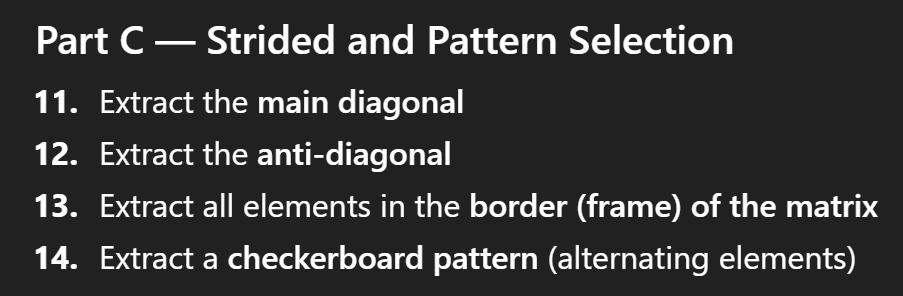

In [19]:
# 11. Extract the main diagonal
print(np.diag(A), "\n")

# 12. Extract the anti-diagonal
print(np.diag(np.fliplr(A)), "\n")

# 13. Extract all elements in the border (frame) of the matrix
top = A[0, :]
left = A[:, 0]
bottom = A[-1, :]
right = A[:, -1]

print(np.concatenate((top, left, bottom, right)), "\n")

# 14.

[ 1  7 13 19 25] 

[ 5  9 13 17 21] 

[ 1  2  3  4  5  1  6 11 16 21 21 22 23 24 25  5 10 15 20 25] 



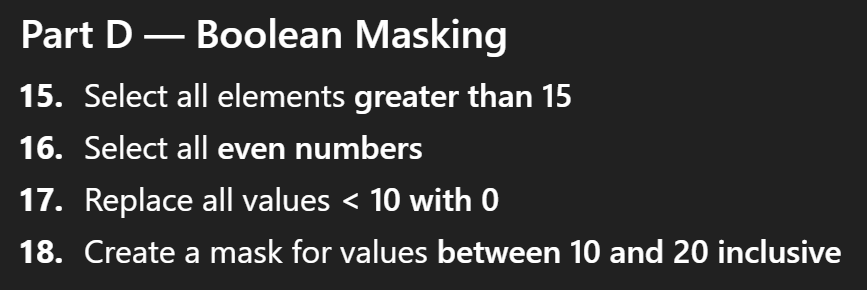

In [20]:
# 15. Select all elements greater than 15
mask = A > 15
print(A[mask], "\n")

# 16. Select all even numbers
mask = (A % 2 == 0)
print(A[mask], "\n")

# 17. Replace all values < 10 with 0
print(np.where(A < 10, 0, A), "\n")

# 18. Create a mask for values between 10 and 20 inclusive
mask = (A >= 10) & (A <= 20)
print(A[mask], "\n")

[16 17 18 19 20 21 22 23 24 25] 

[ 2  4  6  8 10 12 14 16 18 20 22 24] 

[[ 0  0  0  0  0]
 [ 0  0  0  0 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]] 

[10 11 12 13 14 15 16 17 18 19 20] 



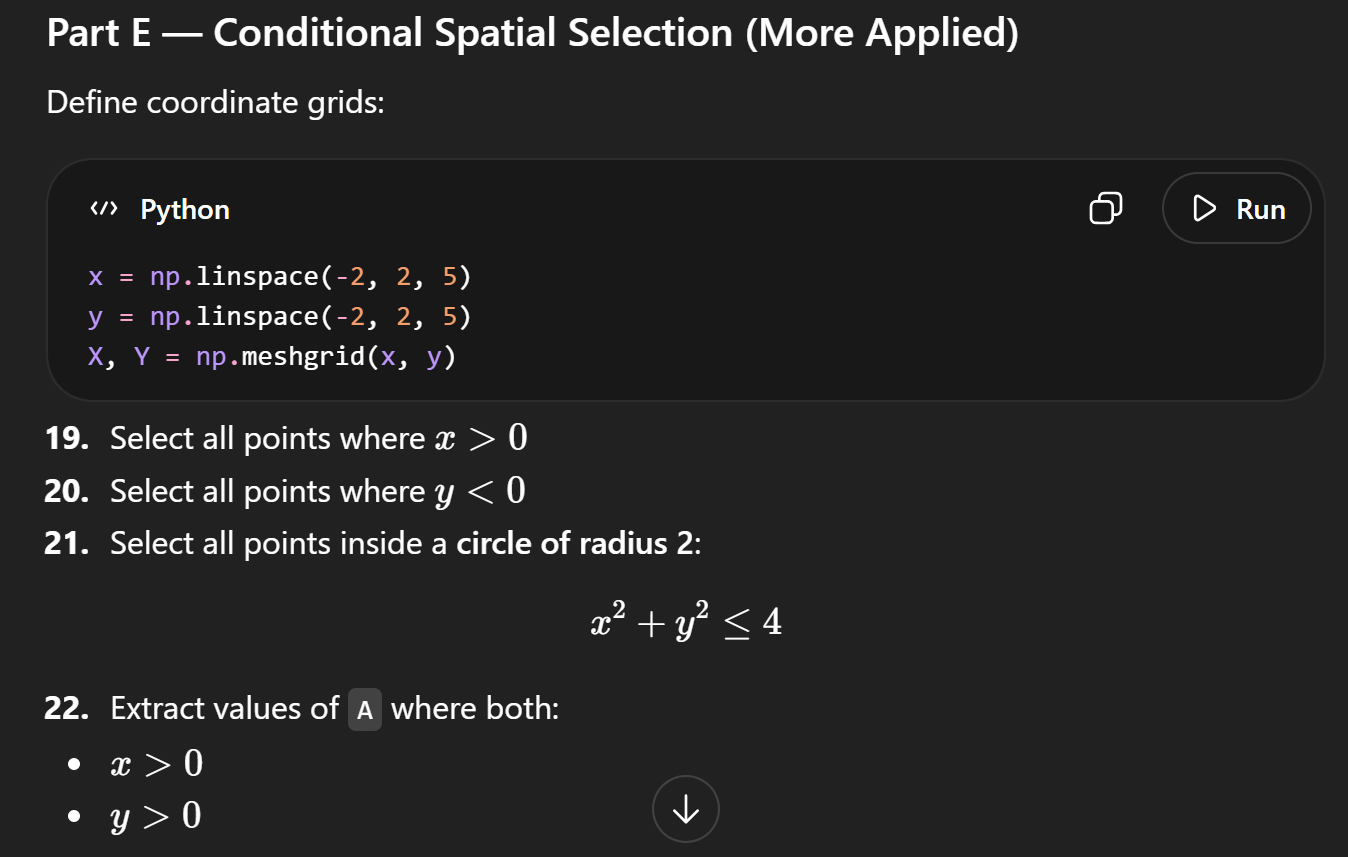

In [21]:
x = np.linspace(-2, 2, 5)
y = np.linspace(-2, 2, 5)
X, Y = np.meshgrid(x, y)

# 19. Select all points where x>0
print(A[X > 0], "\n")

# 20. Select all points where y<0
print(A[Y < 0], "\n")

# 21. inside circle: x^2 + y^2 ≤ 4
mask_circle = X**2 + Y**2 <= 4
A[mask_circle]

[ 4  5  9 10 14 15 19 20 24 25] 

[ 1  2  3  4  5  6  7  8  9 10] 



array([ 3,  7,  8,  9, 11, 12, 13, 14, 15, 17, 18, 19, 23])

In [22]:
X

array([[-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.]])

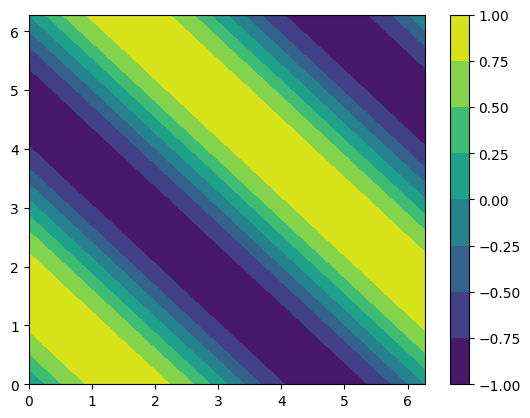

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from src import total_derivatives

x = np.linspace(0, 2*np.pi, 11)
y = np.linspace(0, 2*np.pi, 11)
X, Y = np.meshgrid(x, y)

f = np.sin(X + Y)

fig, ax = plt.subplots()
c = ax.contourf(X, Y, f)
fig.colorbar(c)
plt.show()

In [24]:
j = np.argmin(np.abs(y - 3))
row = f[j, :]

row

array([ 1.22464680e-16, -5.87785252e-01, -9.51056516e-01, -9.51056516e-01,
       -5.87785252e-01, -2.44929360e-16,  5.87785252e-01,  9.51056516e-01,
        9.51056516e-01,  5.87785252e-01,  3.67394040e-16])

In [25]:
total_derivatives.biased_central_difference_approximation(f[j, :], x)

array([-0.93548928, -0.75682673, -0.28908209,  0.28908209,  0.75682673,
        0.93548928,  0.75682673,  0.28908209, -0.28908209, -0.75682673,
       -0.93548928])

In [26]:
dfdx = np.zeros_like(f)

for i in range(f.shape[0]):   # loop over rows (y-direction)
    dfdx[i, :] = total_derivatives.biased_central_difference_approximation(
        f[i, :], x
    )

In [27]:
dfdx

array([[ 9.35489284e-01,  7.56826729e-01,  2.89082087e-01,
        -2.89082087e-01, -7.56826729e-01, -9.35489284e-01,
        -7.56826729e-01, -2.89082087e-01,  2.89082087e-01,
         7.56826729e-01,  9.35489284e-01],
       [ 5.78164173e-01,  2.89082087e-01, -2.89082087e-01,
        -7.56826729e-01, -9.35489284e-01, -7.56826729e-01,
        -2.89082087e-01,  2.89082087e-01,  7.56826729e-01,
         9.35489284e-01,  9.35489284e-01],
       [ 1.76697482e-16, -2.89082087e-01, -7.56826729e-01,
        -9.35489284e-01, -7.56826729e-01, -2.89082087e-01,
         2.89082087e-01,  7.56826729e-01,  9.35489284e-01,
         7.56826729e-01,  5.78164173e-01],
       [-5.78164173e-01, -7.56826729e-01, -9.35489284e-01,
        -7.56826729e-01, -2.89082087e-01,  2.89082087e-01,
         7.56826729e-01,  9.35489284e-01,  7.56826729e-01,
         2.89082087e-01,  1.76697482e-16],
       [-9.35489284e-01, -9.35489284e-01, -7.56826729e-01,
        -2.89082087e-01,  2.89082087e-01,  7.56826729e-01,
  

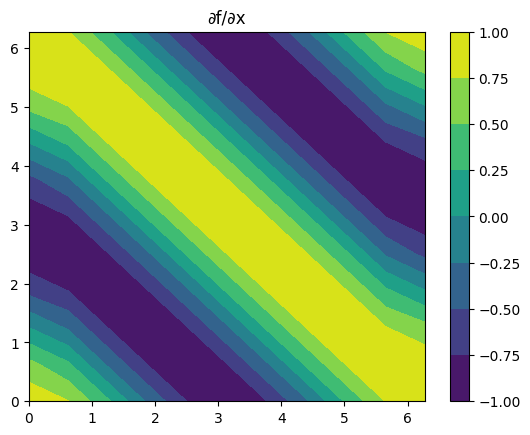

In [28]:
fig, ax = plt.subplots()
c = ax.contourf(X, Y, dfdx)
fig.colorbar(c)
ax.set_title("∂f/∂x")
plt.show()

In [29]:
dfdx = np.apply_along_axis(
    total_derivatives.biased_central_difference_approximation,
    axis=1,
    arr=f,
    domain=x
)

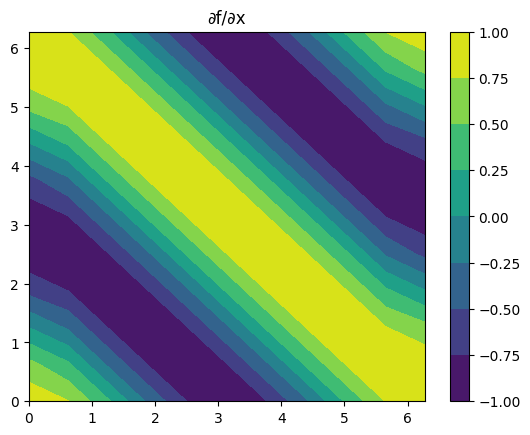

In [30]:
fig, ax = plt.subplots()
c = ax.contourf(X, Y, dfdx)
fig.colorbar(c)
ax.set_title("∂f/∂x")
plt.show()

In [31]:
dfdx

array([[ 9.35489284e-01,  7.56826729e-01,  2.89082087e-01,
        -2.89082087e-01, -7.56826729e-01, -9.35489284e-01,
        -7.56826729e-01, -2.89082087e-01,  2.89082087e-01,
         7.56826729e-01,  9.35489284e-01],
       [ 5.78164173e-01,  2.89082087e-01, -2.89082087e-01,
        -7.56826729e-01, -9.35489284e-01, -7.56826729e-01,
        -2.89082087e-01,  2.89082087e-01,  7.56826729e-01,
         9.35489284e-01,  9.35489284e-01],
       [ 1.76697482e-16, -2.89082087e-01, -7.56826729e-01,
        -9.35489284e-01, -7.56826729e-01, -2.89082087e-01,
         2.89082087e-01,  7.56826729e-01,  9.35489284e-01,
         7.56826729e-01,  5.78164173e-01],
       [-5.78164173e-01, -7.56826729e-01, -9.35489284e-01,
        -7.56826729e-01, -2.89082087e-01,  2.89082087e-01,
         7.56826729e-01,  9.35489284e-01,  7.56826729e-01,
         2.89082087e-01,  1.76697482e-16],
       [-9.35489284e-01, -9.35489284e-01, -7.56826729e-01,
        -2.89082087e-01,  2.89082087e-01,  7.56826729e-01,
  

In [32]:
import numpy as np

import src.total_derivatives


class Partial:
    def __init__(
            self,
            function: np.ndarray,
            x: np.ndarray = None,
            y: np.ndarray = None
    ) -> None:
        self.function = function
        self.x = x if x is not None else np.linspace(0, 1, function.shape[1])
        self.y = y if y is not None else np.linspace(0, 1, function.shape[0])

    def biased_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def biased_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def periodic_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def biased_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

In [33]:
Partial(f, x, y).dx()

AttributeError: 'Partial' object has no attribute 'dx'

In [80]:
f.shape[0]

11

In [81]:
import numpy as np

import src.total_derivatives


class Partial:
    def __init__(
            self,
            function: np.ndarray,
            x: np.ndarray = None,
            y: np.ndarray = None
    ) -> None:
        self.function = function
        self.x = x if x is not None else np.linspace(0, 1, function.shape[1])
        self.y = y if y is not None else np.linspace(0, 1, function.shape[0])

    def biased_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def biased_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def periodic_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def biased_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def biased_dyy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def periodic_dyy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


x = np.linspace(0, 1, 101)
y = np.linspace(0, 1, 101)
X, Y = np.meshgrid(x, y)

psi = X * (1 - X) * Y * (1 - Y)

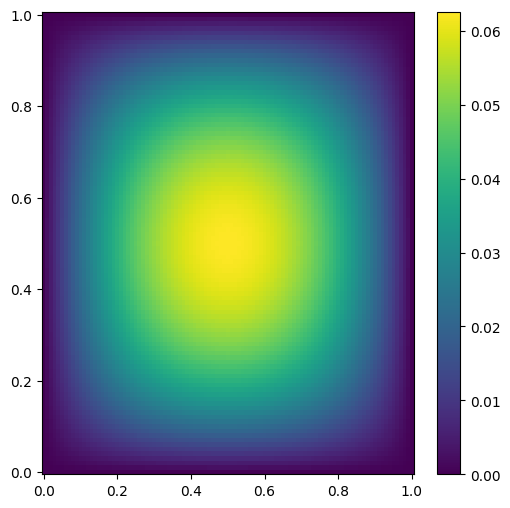

In [82]:
fig, ax = plt.subplots(figsize=(6, 6))
c = ax.pcolormesh(X, Y, psi)
fig.colorbar(c)
plt.show()

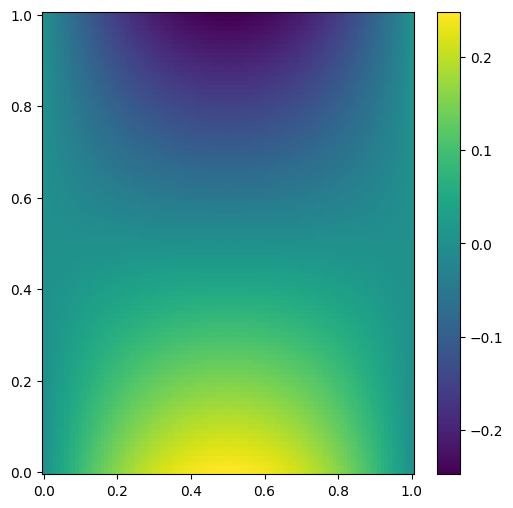

In [83]:
u = Partial(psi, x, y).biased_dy()

fig, ax = plt.subplots(figsize=(6, 6))
c = ax.pcolormesh(X, Y, u)
fig.colorbar(c)
plt.show()



In [53]:
import numpy as np

import src.total_derivatives


class Partial:
    def __init__(
            self,
            function: np.ndarray,
            x: np.ndarray = None,
            y: np.ndarray = None
    ) -> \
            None:
        self.function = function
        self.x = x if x is not None else np.linspace(0, 1, function.shape[1])
        self.y = y if y is not None else np.linspace(0, 1, function.shape[0])


    def x_is_periodic(self) -> bool:
        """
        Check if function is periodic in x-direction.
        Compares first and last columns.
        """
        return np.allclose(self.function[:, 0], self.function[:, -1])


    def y_is_periodic(self) -> bool:
        """
        Check if function is periodic in y-direction.
        Compares first and last rows.
        """
        return np.allclose(self.function[0, :], self.function[-1, :])


    def biased_dx(self) -> np.ndarray:
        """
        Uses central difference approximation for interior points, forward difference approximation
        at the first point, and backwards difference approximation at the last point to compute the
        partial derivative with respect to x-direction in uniform grids.
        """
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def periodic_dx(self) -> np.ndarray:
        """Uses periodic wrapping at boundaries along with central difference approximation
         to compute the partial derivative with respect to x-direction."""
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def biased_dy(self) -> np.ndarray:
        """
        Uses central difference approximation for interior points, forward difference approximation
        at the first point, and backwards difference approximation at the last point to compute the
        partial derivative with respect to y-direction in uniform grids.
        """
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def periodic_dy(self) -> np.ndarray:
        """Uses periodic wrapping at boundaries along with central difference approximation
         to compute the partial derivative with respect to y-direction in uniform grids."""
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def dx(self) -> np.ndarray:
        """
        Compute the partial derivative with respect to x-direction in uniform grids choosing
        the most appropriate scheme to handle the boundary conditions (biased or periodic).
        """
        if self.x_is_periodic():
            return self.periodic_dx()
        else:
            return self.biased_dx()


    def dy(self) -> np.ndarray:
        """
        Compute the partial derivative with respect to y-direction in uniform grids choosing
        the most appropriate scheme to handle the boundary conditions (biased or periodic).
        """
        if self.y_is_periodic():
            return self.periodic_dy()
        else:
            return self.biased_dy()


    def biased_dxx(self) -> np.ndarray:
        """
        Compute the second order partial derivative approximation with respect to x in
        uniform grids using biased forward difference approximation for the
        first step and biased backward difference approximation for the last step.
        """
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def periodic_dxx(self) -> np.ndarray:
        """
        Compute the second order partial derivative approximation in uniform grids
        with respect to the x-direction of the function in uniform grids using the
        periodic boundary condition.
        """
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def biased_dyy(self) -> np.ndarray:
        """
        Compute the second order partial derivative approximation with respect to y in
        uniform grids using biased forward difference approximation for the
        first step and biased backward difference approximation for the last step.
        """
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def periodic_dyy(self) -> np.ndarray:
        """
        Compute the second order partial derivative approximation with respect to the y-direction
        of the function in uniform grids using the periodic boundary condition.
        """
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def dxx(self):
        """Compute the second order partial derivative with respect to x-direction
        with the most appropriate scheme."""
        if self.x_is_periodic():
            return self.periodic_dxx()
        else:
            return self.biased_dxx()


    def dyy(self):
        """Compute the second order partial derivative with respect to y-direction
        with the most appropriate scheme."""
        if self.y_is_periodic():
            return self.periodic_dyy()
        else:
            return self.biased_dyy()


    def at_x0(self, x0: float) -> np.ndarray:
        x0 = np.argmin(self.x - x0)
        return None


    def __str__(self) -> str:
        return (
            f"Partial(field shape = {self.function.shape},"
            f"x = {self.x},"
            f"y = {self.y}),"
            f"x_periodic={self.x_is_periodic()}, "
            f"y_periodic={self.y_is_periodic()})"
        )


    def __repr__(self) -> str:
        return (
            f"Partial(function=np.array(shape={self.function.shape}), "
            f"x=np.array(len={len(self.x)}), "
            f"y=np.array(len={len(self.y)}))"
        )


    def __add__(self, other):
        if not isinstance(other, Partial):
            return NotImplemented

        if self.function.shape != other.function.shape:
            raise ValueError("Function shapes must match.")

        if not np.allclose(self.x, other.x) or not np.allclose(self.y, other.y):
            raise ValueError("Domains must match.")

        return Partial(
            self.function + other.function,
            self.x,
            other.y
        )

    def __sub__(self, other):
        if not isinstance(other, Partial):
            return NotImplemented

        if self.function.shape != other.function.shape:
            raise ValueError("Function shapes must match.")

        if not np.allclose(self.x, other.x) or not np.allclose(self.y, other.y):
            raise ValueError("Domains must match.")

        return Partial(
            self.function - other.function,
            self.x,
            other.y
        )

    def __mul__(self, other: float):
        return Partial(self.function * other, self.x, self.y)

# Setup Grid
x = np.linspace(0, 1, 101)
y = np.linspace(0, 1, 101)
X, Y = np.meshgrid(x, y)

# Define stream function
psi = X * (1 - X) * Y * (1 - Y)

# Define wind components
u = Partial(psi, x, y).biased_dy()
v = - Partial(psi, x, y).biased_dx()

# Define vorticity
vorticity = - Partial(psi, x, y).biased_dxx() - Partial(psi, x, y).biased_dyy()
# vorticity = Partial(v, x, y).biased_dx() - Partial(u, x, y).biased_dy()

# Define enstrophy
enstrophy_density = 0.5 * vorticity**2

# Define divergence
divergence = Partial(u, x, y).biased_dx() + Partial(v, x, y).biased_dy()

# Define strain
strain = 0.5 * (Partial(psi, x, y).biased_dyy() - Partial(psi, x, y).biased_dxx())


print(psi)

[[0.0000e+00 0.0000e+00 0.0000e+00 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 9.8010e-05 1.9404e-04 ... 1.9404e-04 9.8010e-05 0.0000e+00]
 [0.0000e+00 1.9404e-04 3.8416e-04 ... 3.8416e-04 1.9404e-04 0.0000e+00]
 ...
 [0.0000e+00 1.9404e-04 3.8416e-04 ... 3.8416e-04 1.9404e-04 0.0000e+00]
 [0.0000e+00 9.8010e-05 1.9404e-04 ... 1.9404e-04 9.8010e-05 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 ... 0.0000e+00 0.0000e+00 0.0000e+00]]


In [35]:
psi.shape

(101,)

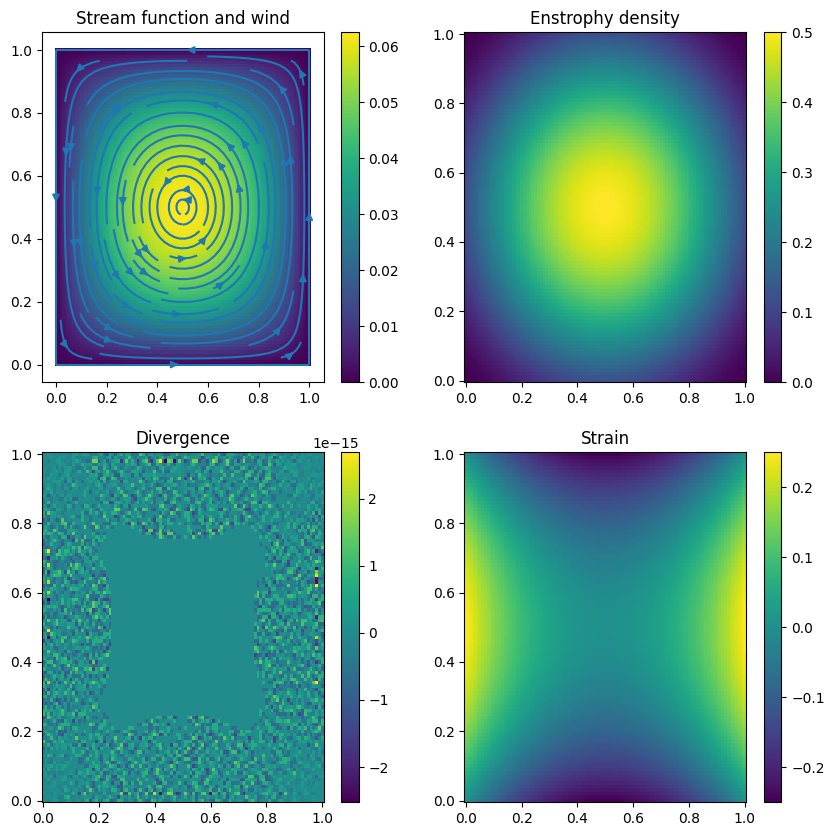

In [54]:
import matplotlib.pyplot as plt

step = 5

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

# Stream Function and wind
c1 = ax1.pcolormesh(X, Y, psi)
ax1.set_title("Stream function and wind")
ax1.streamplot(X[::step, ::step], Y[::step, ::step], u[::step, ::step], v[::step, ::step])
fig.colorbar(c1)

# Enstrophy
c2 = ax2.pcolormesh(X, Y, enstrophy_density)
ax2.set_title("Enstrophy density")
fig.colorbar(c2)

# Divergence
c3 = ax3.pcolormesh(X, Y, divergence)
ax3.set_title("Divergence")
fig.colorbar(c3)

# Strain
c4 = ax4.pcolormesh(X, Y, strain)
ax4.set_title("Strain")
fig.colorbar(c4)

plt.show()

In [97]:
u

array([[ 0.      ,  0.009801,  0.019404, ...,  0.019404,  0.009801,
         0.      ],
       [ 0.      ,  0.009702,  0.019208, ...,  0.019208,  0.009702,
         0.      ],
       [ 0.      ,  0.009504,  0.018816, ...,  0.018816,  0.009504,
         0.      ],
       ...,
       [ 0.      , -0.009504, -0.018816, ..., -0.018816, -0.009504,
         0.      ],
       [ 0.      , -0.009702, -0.019208, ..., -0.019208, -0.009702,
         0.      ],
       [ 0.      , -0.009801, -0.019404, ..., -0.019404, -0.009801,
         0.      ]])

In [6]:
import numpy as np

def build_matrix(n):
    A = np.zeros((n, n))

    # interior 1/2 bands
    # A += np.diag(0.5 * np.ones(n-1), k=1)
    # A += np.diag(0.5 * np.ones(n-1), k=-1)

    # # first row
    # A[0, 0] = h
    #
    # # second row: [0, 1, 1, 0, ...]
    # A[1, 1] = 1
    # A[1, 2] = 1
    #
    # # last row: [..., 1, 1]
    # A[-1, -2] = 1
    # A[-1, -1] = 1

    return A

A = build_matrix(5)
A


array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [11]:
A = np.zeros((5, 5))
A += np.diag

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [13]:
A = np.ones((2, 2))
B = np.zeros((2, 2))

H = np.hstack((A, B))
V = np.vstack((A, B))

V

array([[1., 1.],
       [1., 1.],
       [0., 0.],
       [0., 0.]])

In [15]:
M = np.block([
    [A, B],
    [B, A]
])

M

array([[1., 1., 0., 0.],
       [1., 1., 0., 0.],
       [0., 0., 1., 1.],
       [0., 0., 1., 1.]])

In [16]:
A = np.zeros((4, 4))

A[0, :] = 1        # first row
A[:, 0] = 2        # first column
A[1:3, 1:3] = 5    # submatrix

A

array([[2., 1., 1., 1.],
       [2., 5., 5., 0.],
       [2., 5., 5., 0.],
       [2., 0., 0., 0.]])

In [18]:
n = 4

main = 2 * np.ones(n)
upper = -1 * np.ones(n-1)
lower = -1 * np.ones(n-1)

A = np.diag(main) + np.diag(upper, 1) + np.diag(lower, -1)

In [24]:
np.diag(main)

array([[2., 0., 0., 0.],
       [0., 2., 0., 0.],
       [0., 0., 2., 0.],
       [0., 0., 0., 2.]])

In [25]:
np.diag(upper, 1)

array([[ 0., -1.,  0.,  0.],
       [ 0.,  0., -1.,  0.],
       [ 0.,  0.,  0., -1.],
       [ 0.,  0.,  0.,  0.]])

In [26]:
A = (
    np.diag(np.ones(5)) +
    np.diag(2*np.ones(4), 1) +
    np.diag(3*np.ones(4), -1)
)
A

array([[1., 2., 0., 0., 0.],
       [3., 1., 2., 0., 0.],
       [0., 3., 1., 2., 0.],
       [0., 0., 3., 1., 2.],
       [0., 0., 0., 3., 1.]])

In [40]:
A = np.zeros((10, 10))
A += np.diag(0.5 * np.ones(10-1), k=1)
A += np.diag(0.5 * np.ones(10-1), k=-1)
A[0, 0:2] = np.array([-1, 1])
A[-1, -2:] = np.array([-1, 1])
A

array([[-1. ,  1. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0.5,  0. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0.5,  0. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0.5,  0. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0.5,  0. ,  0.5,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0.5,  0. ,  0.5,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0.5,  0. ,  0.5,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0.5,  0. ,  0.5,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0.5,  0. ,  0.5],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. , -1. ,  1. ]])

In [6]:
def transformation_matrix(n: int) -> np.ndarray:
    """Defines the n x n transformation matrix necessary to solve the problem."""
    H = np.zeros((n, n))
    H += np.diag(0.5 * np.ones(n - 1), k=1)
    H += np.diag(-0.5 * np.ones(n - 1), k=-1)
    H[0, :2] = np.array([-1, 1])
    H[-1, -2:] = np.array([-1, 1])
    return H

In [9]:
A = transformation_matrix(10)
PI = np.ones_like(A)
A - PI

array([[-2. ,  0. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. ],
       [-1.5, -1. , -0.5, -1. , -1. , -1. , -1. , -1. , -1. , -1. ],
       [-1. , -1.5, -1. , -0.5, -1. , -1. , -1. , -1. , -1. , -1. ],
       [-1. , -1. , -1.5, -1. , -0.5, -1. , -1. , -1. , -1. , -1. ],
       [-1. , -1. , -1. , -1.5, -1. , -0.5, -1. , -1. , -1. , -1. ],
       [-1. , -1. , -1. , -1. , -1.5, -1. , -0.5, -1. , -1. , -1. ],
       [-1. , -1. , -1. , -1. , -1. , -1.5, -1. , -0.5, -1. , -1. ],
       [-1. , -1. , -1. , -1. , -1. , -1. , -1.5, -1. , -0.5, -1. ],
       [-1. , -1. , -1. , -1. , -1. , -1. , -1. , -1.5, -1. , -0.5],
       [-1. , -1. , -1. , -1. , -1. , -1. , -1. , -1. , -2. ,  0. ]])

In [10]:
np.linalg.inv(A - PI)

array([[-2.15389547e+15,  4.30779095e+15, -4.30779095e+15,
         4.30779095e+15, -4.30779095e+15,  4.30779095e+15,
        -4.30779095e+15,  4.30779095e+15, -4.30779095e+15,
         2.15389547e+15],
       [-1.66437378e+15,  3.32874755e+15, -3.32874755e+15,
         3.32874755e+15, -3.32874755e+15,  3.32874755e+15,
        -3.32874755e+15,  3.32874755e+15, -3.32874755e+15,
         1.66437378e+15],
       [-1.17485208e+15,  2.34970415e+15, -2.34970415e+15,
         2.34970415e+15, -2.34970415e+15,  2.34970415e+15,
        -2.34970415e+15,  2.34970415e+15, -2.34970415e+15,
         1.17485208e+15],
       [-6.85330378e+14,  1.37066076e+15, -1.37066076e+15,
         1.37066076e+15, -1.37066076e+15,  1.37066076e+15,
        -1.37066076e+15,  1.37066076e+15, -1.37066076e+15,
         6.85330378e+14],
       [-1.95808679e+14,  3.91617359e+14, -3.91617359e+14,
         3.91617359e+14, -3.91617359e+14,  3.91617359e+14,
        -3.91617359e+14,  3.91617359e+14, -3.91617359e+14,
         1.

In [13]:
# %%
import matplotlib.pyplot as plt
import numpy as np


g = 9.81
Rd = 287.1
gamma = 6.5e-3

n = 1_001
z = np.linspace(0, 100_000, n)
theta_profile  = 300.0 + gamma * z
exner_0 = 1
exner_0_vector = exner_0 * np.ones(n)
h = z[1] - z[0]


def exner(theta: float | np.ndarray) -> float | np.ndarray:
    exner_profile = - g / (Rd * theta)
    return exner_profile


def transformation_matrix(n: int) -> np.ndarray:
    """Defines the n x n transformation matrix necessary to solve the problem."""
    H = np.zeros((n, n))
    H += np.diag(0.5 * np.ones(n - 1), k=1)
    H += np.diag(-0.5 * np.ones(n - 1), k=-1)
    H[0, :2] = np.array([-1, 1])
    H[-1, -2:] = np.array([-1, 1])
    return H


H = transformation_matrix(n)
dpi_dz = exner(theta_profile)
hydrostatic_pressure = h * np.linalg.inv(H - exner_0_vector) @ dpi_dz

print(hydrostatic_pressure.shape)

# y = exner(theta_profile)
#
# fig, ax = plt.subplots()
# ax.plot(y, z)
# plt.show()

(1001,)


In [12]:
dpi_dz.shape

(1001,)

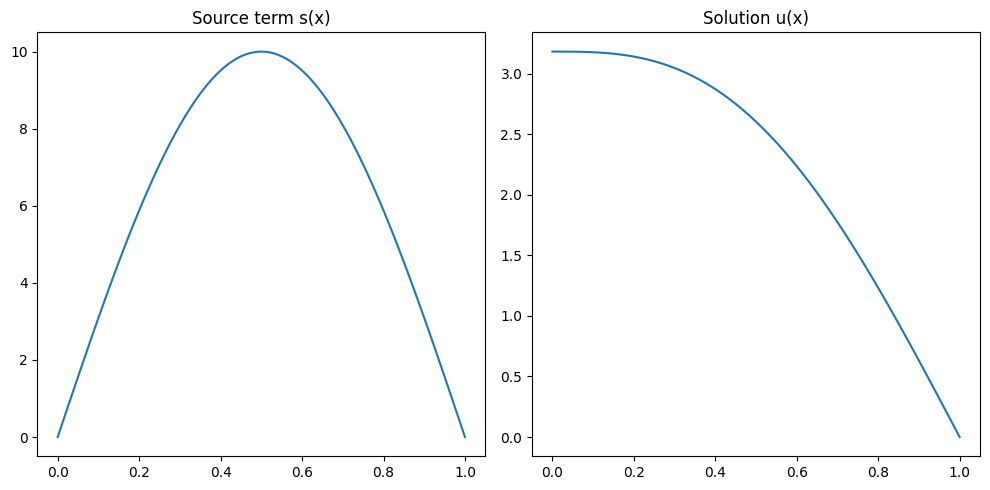

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Grid ---
n = 101
x = np.linspace(0, 1, n)
dx = x[1] - x[0]

# --- Source term ---
def s_func(x):
    return 10 * np.sin(np.pi * x)

# --- Matrix builder ---
def diffusion_matrix(n: int, dx: float) -> np.ndarray:
    H = np.zeros((n, n))

    # Interior: second-order centered difference
    H += np.diag(-1 * np.ones(n - 1), k=1)
    H += np.diag(2 * np.ones(n))
    H += np.diag(-1 * np.ones(n - 1), k=-1)

    # Scale interior rows
    H[1:-1, :] /= dx**2

    # Bottom boundary (Neumann): du/dx = alpha
    H[0, :3] = np.array([-1.5, 2.0, -0.5]) / dx

    # Top boundary (Dirichlet): u = beta
    H[-1, :] = 0
    H[-1, -1] = 1.0

    return H

# --- RHS vector ---
def rhs_vector(x, dx, alpha, beta):
    n = len(x)
    b = np.zeros(n)

    s = s_func(x)

    # Bottom boundary
    b[0] = alpha

    # Interior (note: NO dx^2 scaling since it's already in matrix)
    b[1:-1] = s[1:-1]

    # Top boundary
    b[-1] = beta

    return b

# --- Parameters ---
alpha = 0.0   # bottom flux
beta = 0.0    # top value

# --- Build system ---
H = diffusion_matrix(n, dx)
b = rhs_vector(x, dx, alpha, beta)

# --- Solve ---
u = np.linalg.solve(H, b)

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(x, s_func(x))
ax1.set_title("Source term s(x)")

ax2.plot(x, u)
ax2.set_title("Solution u(x)")

plt.tight_layout()
plt.show()

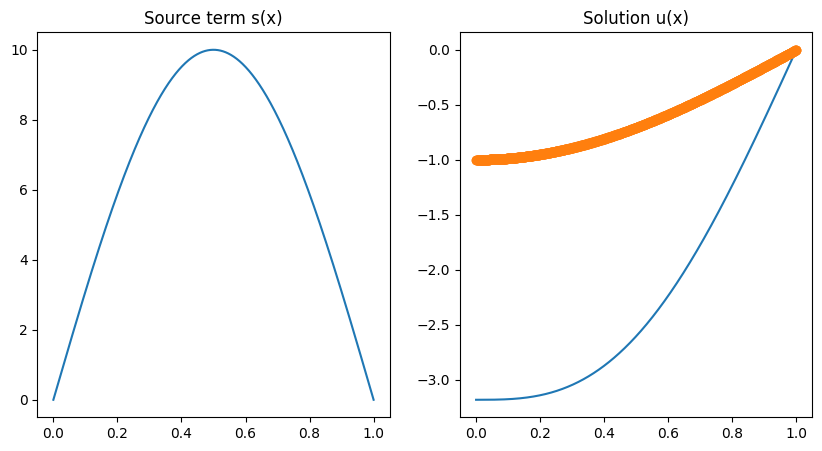

In [83]:
# %%
import matplotlib.pyplot as plt
import numpy as np


n = 1001
x = np.linspace(0, 1, n)
dx = x[1] - x[0]
s1 = 10 * np.sin(np.pi * x)
s2 = (0.5 * np.pi)**2 * np.cos(0.5 * np.pi * x)
u_analytic = - np.cos(0.5 * np.pi * x)
bcs = np.zeros_like(x)
bcs_0 = s


def diffusion_matrix(n: int) -> np.ndarray:
    """Defines the n x n transformation matrix necessary to solve the diffusion problem."""
    H = np.zeros((n, n))
    H += np.diag(-1 * np.ones(n - 1), k=1)
    H += np.diag(2 * np.ones(n))
    H += np.diag(-1 * np.ones(n - 1), k=-1)
    H[0, :3] = np.array([-1.5, 2.0, -0.5])
    H[-1, :] = 0
    H[-1, -1] = 1.0
    return H


def bcs(lower: float, upper: float, function: np.ndarray) -> np.ndarray:
    """
    Boundary conditions vector given the values of the lower boundary, upper boundary and the
    function.
    """
    bcs_vector = np.zeros_like(function)
    bcs_vector[0] = lower
    bcs_vector[-1] = upper
    return bcs_vector

H = diffusion_matrix(n)

u = np.linalg.inv(H) @ (s1 * -dx**2 + bcs(0, 0, s1))
# y = 10 / ((np.pi)**2) * np.sin(np.pi * x)
y = x**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("Source term s(x)")
ax1.plot(x, s1)
ax2.set_title("Solution u(x)")
ax2.plot(x, u)
ax2.plot(x, u_analytic, marker="o")

plt.show()

In [62]:
n = 200
x = np.linspace(0, 1, n)
dx = x[1] - x[0]
s1 = 10 * np.sin(np.pi * x)
s2 = (0.5 * np.pi)**2 * np.cos(0.5 * np.pi * x)
u_analytic = - np.cos(0.5 * np.pi * x)
bcs = np.zeros_like(u_analytic)

lower = 0.5 * (-3*s1[2] + 4*s1[1] - s1[0]) / dx

bcs[0] = lower

bcs

array([-31.40287783,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.  

In [63]:
import sympy as smp
x = smp.Symbol('x')

s1 = -10 * smp.sin(smp.pi * x)

I1 = smp.integrate(s1, x)
I2 = smp.integrate(I1, x)
I2

10*sin(pi*x)/pi**2

In [71]:
I2.diff().doit()

10*cos(pi*x)/pi

In [5]:
import numpy as np

n = 5
H = np.zeros((n, n))
H

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [11]:
np.diag(-1 * np.ones(n - 1), k=-1)

array([[ 0.,  0.,  0.,  0.,  0.],
       [-1.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  0.,  0.,  0.],
       [ 0.,  0., -1.,  0.,  0.],
       [ 0.,  0.,  0., -1.,  0.]])

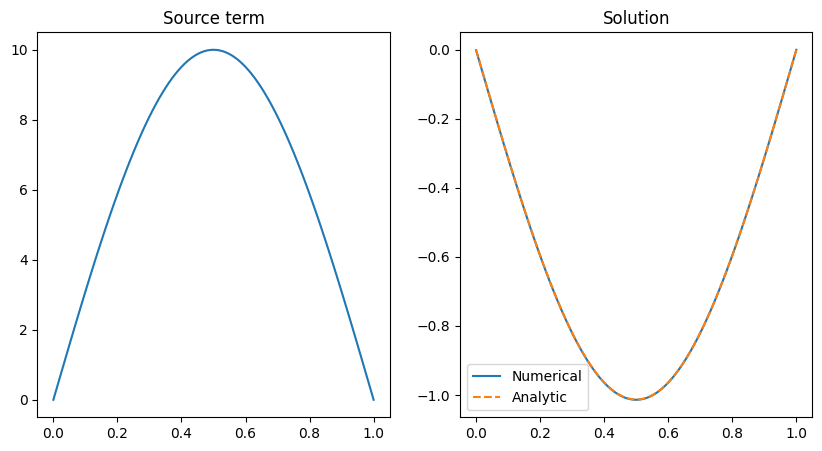

In [86]:
import matplotlib.pyplot as plt
import numpy as np


def bcs(lower, upper, function):
    bc = np.zeros_like(function)
    bc[0] = lower
    bc[-1] = upper
    return bc


def diffusion_matrix(n):
    H = np.zeros((n, n))

    # Interior stencil
    H += np.diag(-np.ones(n - 1), 1)
    H += np.diag(2 * np.ones(n), 0)
    H += np.diag(-np.ones(n - 1), -1)

    # Neumann BC at bottom
    H[0, :] = 0
    H[0, :3] = [1.5, -2.0, 0.5]

    # Dirichlet BC at top
    H[-1, :] = 0
    H[-1, -1] = 1

    return H


n = 101
x = np.linspace(0, 1, n)
dx = x[1] - x[0]

s1 = 10 * np.sin(np.pi * x)

# Correct analytic solution
u_analytic = -(10 / np.pi**2) * np.sin(np.pi * x)

H = diffusion_matrix(n)

alpha = 10 / np.pi
beta = 0

lower = dx * alpha
upper = beta

bc = bcs(lower, upper, s1)

rhs = -dx**2 * s1 + bc

u = np.linalg.solve(H, rhs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.set_title("Source term")
ax1.plot(x, s1)

ax2.set_title("Solution")
ax2.plot(x, u, label="Numerical")
ax2.plot(x, u_analytic, "--", label="Analytic")

ax2.legend()

plt.show()